In [224]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from tqdm import tqdm
from sklearn.metrics import mean_squared_error
from filterpy.monte_carlo import (
    multinomial_resample, residual_resample, systematic_resample, stratified_resample
)
sys.path.append('../src')
from data_loader import DataLoader
import scipy.stats as stats
from scipy.stats import multivariate_normal, chi2, norm
from kalman_filters.particle_filter import ResamplingAlgorithms
from numpy.linalg import norm


%matplotlib inline
np.random.seed(777)

Loading calibration files.
Transform GPS data into imu coordinate.
Transform VO data into imu coordinate.
Data size: 1591
Shape:
GPS: (1591, 3)
VO: (1591, 3)
IMU: (1591, 6)
INS angle: (1591, 3)
INS velocity: (1591, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data


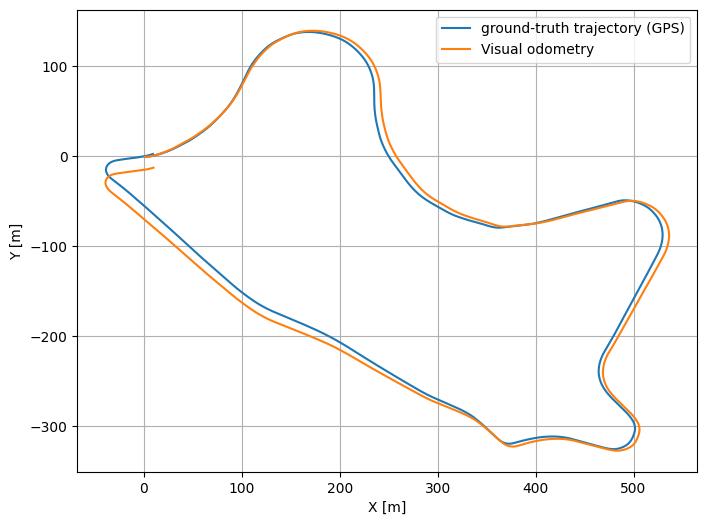

In [257]:
kitti_root_dir = '../data'
kitti_date = '2011_09_30'
kitti_drive = '0033'

data = DataLoader(sequence_nr=kitti_drive, gps_dropout_ratio=0.2, vo_dropout_ratio=0.2)

In [385]:
class KLD_ParticleFilter:

    weights = None
    def __init__(self, 
                 N, 
                 x_dim, 
                 H,
                 delta,
                 epsilon,
                 resolutions,
                 min_n_particles=32,
                 max_n_particles=2**14,
                 resampling_algorithm=ResamplingAlgorithms.MULTINOMIAL):
        
        self.particles = np.empty((N, x_dim))
        self.N_original = N
        self.N = N
        self.H = H

        self.epsilon = epsilon
        self.delta = delta
        self.min_n_particles = min_n_particles
        self.max_n_particles = max_n_particles
        self.resolutions = resolutions

        self.weights = np.ones(self.N) / self.N
        self.resampling_algorithm = resampling_algorithm
    
    def create_uniform_particles(self, x_range):
        for i, x in enumerate(x_range):
            self.particles[:, i] = np.random.uniform(x[0], x[1], size=self.N)

    def create_gaussian_particles(self, mean, var):
        self.particles = mean.reshape(-1) + np.array([np.random.randn(self.N) for _ in range(var.shape[0])]).T @ var

    def compute_norm_w(self, w):
        return np.sqrt(np.sum(w**2))

    def get_rotation_matrix(self, q):
        q1, q2, q3, q4 = q[:, 0]
        return np.array([
            [q1**2 + q2**2 - q3**2 - q4**2, 2*(q2*q3 - q1*q4), 2*(q1*q3 + q2*q4)],
            [2*(q2*q3 + q1*q4), q1**2 - q2**2 + q3**2 - q4**2, 2*(q3*q4 - q1*q2)],
            [2*(q2*q4 - q1*q3), 2*(q1*q2 + q3*q4), q1**2 - q2**2 - q3**2 + q4**2]
           ])
    def get_quaternion_update_matrix(self, w):
        wx, wy, wz = w[:, 0]
        return np.array([
            [0, wz, -wy, wx],
            [-wz, 0, wx, wy],
            [wy, -wx, 0, wz],
            [-wx, -wy, -wz, 0]
        ])

    def draw_random_particle(self):
        Q = np.cumsum(self.weights).tolist()
        u = np.random.uniform(1e-6, Q[-1], 1)[0]
        index = 0
        while Q[index] < u:
            index += 1
        return self.particles[index]

    def propagate_particle(self, particle, u, dt, Q):
        """ 
            move according to control input u (heading change, velocity) with noise std
            u: control input vector
            process_noise_vector: process noise vector
            dt: delta time
        """
        p = particle[:3]
        v = particle[3:6]
        q = particle[6:]
        
        a = u[:3]
        w = u[3:]
        a = a.reshape(-1, 1)
        w = w.reshape(-1, 1)
        g = np.array([[0],[0],[9.81]])
        R = self.get_rotation_matrix(q) #3x3
        omega = self.get_quaternion_update_matrix(w)
        norm_w = self.compute_norm_w(w)

        A = np.cos(norm_w*dt/2) * np.eye(4)
        B = (1/norm_w)*np.sin(norm_w*dt/2) * omega
        
        # predict state vector x
        p_k = p + v * dt + (R @ a - g)*dt**2 / 2
        v_k = v + (R @ a - g) * dt
        q_k = np.array(A + B) @ q
        propagated_particle = np.concatenate([
            p_k,
            v_k,
            q_k,
        ]).reshape(-1)
        return np.random.multivariate_normal(propagated_particle, Q, 1)

    def update_particle(self, particle, z, R):
        """ 
            calculate the likelihood p(zk|xk)
            z: measurement
            R: measurement noise covariance
        """
        target_distribution = multivariate_normal(mean=z, cov=R)
        y_hat = self.H @ particle #+ np.random.multivariate_normal(np.zeros(R.shape[0]), R, 1).reshape(-1) 
        return target_distribution.pdf(y_hat)
        
    def run(self, u, dt, Q, z, R):
        new_particles = []
        new_weights = []

        k = 0
        bins_with_support = []
        number_of_new_particles = 0
        number_of_required_particles = self.min_n_particles
        while number_of_new_particles < number_of_required_particles:
            # Get sample from discrete distribution given by particle weights
            particle = self.draw_random_particle()

            # propagate a selected particle
            propagated_particle = self.propagate_particle(
                particle=particle.reshape(-1, 1),
                u=u,
                dt=dt,
                Q=Q)
            # compute likelihood (weight of the propagated particle in the measurement space)
            importance_weight = self.update_particle(particle=propagated_particle.reshape(-1), z=z, R=R)
            
            new_particles.append(propagated_particle.reshape(-1).tolist())
            new_weights.append(importance_weight)
            number_of_new_particles += 1
            
            indices = np.floor(propagated_particle.reshape(-1) / self.resolutions).tolist()[:2]
            # indices = np.concatenate([indices[:2], indices[6:]]).tolist()
            if indices not in bins_with_support:
                bins_with_support.append(indices)
                k += 1
                
            if k > 1:
                # upper_quantile = np.sqrt(chi2.pdf(1-self.delta, df=k))
                upper_quantile = stats.norm.ppf(1-self.delta)
                number_of_required_particles = self.compute_required_number_of_particles_kld(
                                                k=k, 
                                                upper_quantile=upper_quantile)
                                                                                        
            # Make sure number of particles constraints are not violated
            number_of_required_particles = max(number_of_required_particles, self.min_n_particles)
            number_of_required_particles = min(number_of_required_particles, self.max_n_particles)


        self.particles = np.array(new_particles)
        self.weights = np.array(new_weights)
        self.weights += 1.e-300 # avoiding dividing by zero
        self.weights /= sum(self.weights) # normalize
        self.N = self.particles.shape[0]
        

    def calculate_ess(self):
        return 1. / np.sum(np.square(self.weights))
        
    def estimate(self):
        """ returns mean and variance """
        pos = self.particles
        mu = np.average(pos, weights=self.weights, axis=0)
        var = np.average((pos - mu)**2, weights=self.weights, axis=0)

        return mu, var
        
    def compute_required_number_of_particles_kld(self, k, upper_quantile):
        """
        Compute the number of samples needed within a particle filter when k bins in the multidimensional histogram contain
        samples. Use Wilson-Hilferty transformation to approximate the quantiles of the chi-squared distribution as proposed
        by Fox (2003).
    
        :param epsilon: Maxmimum allowed distance (error) between true and estimated distribution.
        :param upper_quantile: Upper standard normal distribution quantile for (1-delta) where delta is the probability that
        the error on the estimated distribution will be less than epsilon.
        :param k: Number of bins containing samples.
        :return: Number of required particles.
        """
        # Helper variable (part between curly brackets in (14) in Fox paper
        x = 1.0 - 2.0 / (9.0*(k-1)) + np.sqrt(2.0 / (9.0*(k-1))) * upper_quantile
        return np.ceil((k-1) / (2.0*self.epsilon) * x * x * x)
        
    def resample_from_index(self, indexes):
        assert len(indexes) == self.N
        
        self.particles = self.particles[indexes]
        self.weights = self.weights[indexes]
        self.weights /= np.sum(self.weights)

    def resample(self):
        if self.resampling_algorithm is ResamplingAlgorithms.RESIDUAL:
            indexes = residual_resample(self.weights)
        elif self.resampling_algorithm is ResamplingAlgorithms.STRATIFIED:
            indexes = stratified_resample(self.weights)
        elif self.resampling_algorithm is ResamplingAlgorithms.SYSTEMATIC:
            indexes = systematic_resample(self.weights)
        else:
            # ResamplingAlgorithms.MULTINOMIAL
            indexes = multinomial_resample(self.weights)
        
        self.resample_from_index(indexes)

In [391]:
# initial values
px_, py_, pz_ = data.VO_measurements[0, :]
q1_, q2_, q3_, q4_ = data.IMU_quaternion[0]

x = np.array([
    [px_], #Px
    [py_], #Py
    [pz_], #Pz
    [0], #Vx
    [0], #Vy
    [0], #Vz
    [q1_], #q1
    [q2_], #q2
    [q3_], #q3
    [q4_]  #q4
])


i = np.eye(x.shape[0])
# covariance for state vector x
state_error_vector = [
    1, 
    1, 
    1, 
    0.1, 
    0.1, 
    0.1,
    0, #data.IMU_angular_velocity_noise_std, 
    0, #data.IMU_angular_velocity_noise_std, 
    0, #data.IMU_angular_velocity_noise_std, 
    0, #data.IMU_angular_velocity_noise_std
]
P = np.array([[val * num for num in i[ind]] for ind, val in enumerate(state_error_vector)]) 

# transition matrix from predicted state vector to measurement space
H = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]
])
# H = np.array([
#     [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
#     [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]
# ])
# process noise
process_noise_vector =  [
    10, #data.VO_noise_std, 
    10, #data.VO_noise_std, 
    10, #data.VO_noise_std,
    0.1, 
    0.1, 
    0.1,
    data.IMU_angular_velocity_noise_std, 
    data.IMU_angular_velocity_noise_std, 
    data.IMU_angular_velocity_noise_std, 
    data.IMU_angular_velocity_noise_std
]
Q = np.array([[val * num for num in i[ind]] for ind, val in enumerate(process_noise_vector)])
# measurement noise
VO_noise_std2 = data.VO_noise_std
GPS_measurement_noise_std2 = data.GPS_measurement_noise_std

R = np.array([
    [VO_noise_std2 ** 2., 0., 0., 0.],
    [0., VO_noise_std2 ** 2., 0., 0.],
    [0., 0., GPS_measurement_noise_std2 ** 2., 0.],
    [0., 0., 0., GPS_measurement_noise_std2 ** 2.]
])

R_vo = np.array([
    [VO_noise_std2 ** 2., 0.],
    [0., VO_noise_std2 ** 2.],
])
R_gps = np.array([
    [GPS_measurement_noise_std2 ** 2., 0.],
    [0., GPS_measurement_noise_std2 ** 2.],
])

min_number_of_particles = 256
max_number_of_particles = 2**14
epsilon = 0.15
delta=0.1
resolutions = np.array([
            5, 5, 5,
            10, 10, 10,
            0.1, 0.2, 0.2, 0.1
        ])

In [392]:
kld_pf = KLD_ParticleFilter(N=min_number_of_particles, 
                            x_dim=x.shape[0],
                            H=H,
                            delta=delta,
                            epsilon=epsilon,
                            resolutions=resolutions,
                            min_n_particles=min_number_of_particles,
                            max_n_particles=max_number_of_particles,
                            resampling_algorithm=ResamplingAlgorithms.RESIDUAL)
kld_pf.create_gaussian_particles(mean=x, var=P)

  6%|█████▊                                                                                                    | 88/1590 [00:04<01:25, 17.52it/s]

at index: 86, N: 260
at index: 87, N: 311
at index: 88, N: 322
at index: 89, N: 366


  6%|██████                                                                                                    | 90/1590 [00:05<01:23, 17.96it/s]

at index: 90, N: 443
at index: 91, N: 518


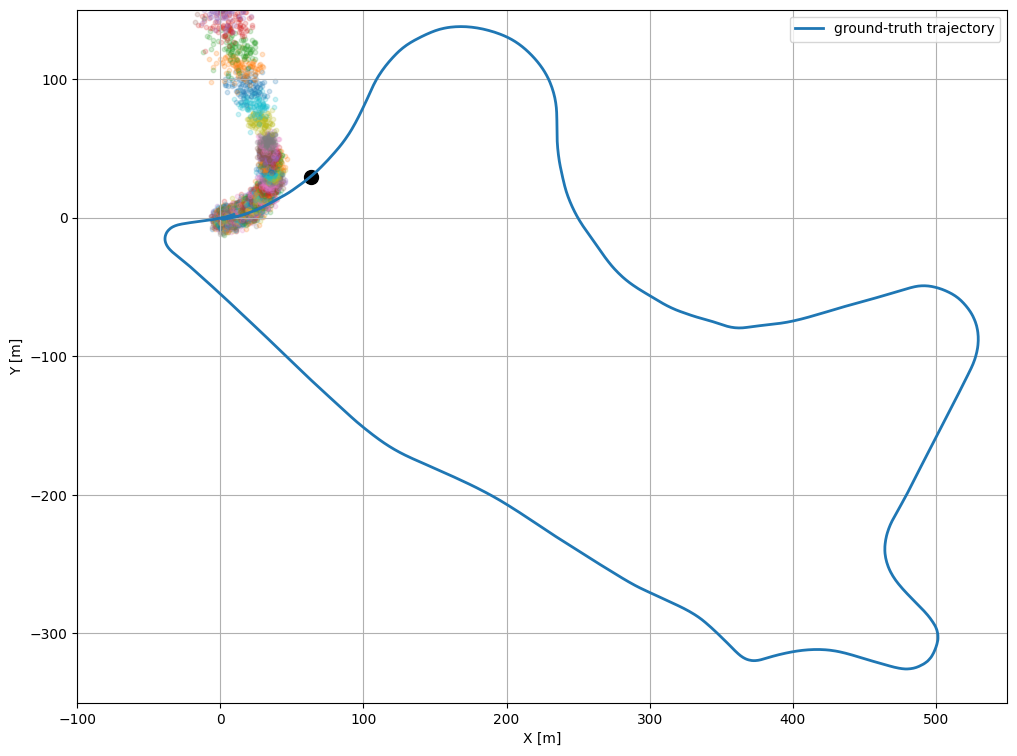

In [393]:
mu_x_kld_pf = [x[0, 0],]
mu_y_kld_pf = [x[1, 0],]
t_last = 0.

fig, ax = plt.subplots(1, 1, figsize=(12, 9))
xs, ys, _ = data.GPS_measurements_in_meter.T
ax.plot(xs, ys, lw=2, label='ground-truth trajectory')
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.set_xlim([-100, 550])
ax.set_ylim([-350, 150])
ax.legend()
ax.grid()

n = kld_pf.N
for t_idx in tqdm(range(1, data.N)):
    t = data.ts[t_idx]
    dt = t - t_last
    ax_, ay_, az_ = data.IMU_acc_with_noise[t_idx]
    wx_, wy_, wz_ = data.IMU_angular_velocity_with_noise[t_idx]
    u = np.array([
        ax_,
        ay_,
        az_,
        wx_,
        wy_,
        wz_
    ])
    
    # vo_z = data.VO_measurements_with_noise[t_idx, :2]
    # gps_z = data.GPS_mesurement_in_meter_with_noise[t_idx, :2]


    # vo_z = data.get_vo_measurement(t_idx).reshape(-1)
    # gps_z = data.get_gps_measurement(t_idx).reshape(-1)
    
    # if vo_z is not None:
    #     kld_pf.run(u=u, dt=dt, Q=Q, z=vo_z, R=R_vo)
    # if gps_z is not None:
    #     kld_pf.run(u=u, dt=dt, Q=Q, z=gps_z, R=R_gps)
    # kld_pf.run(u=u, dt=dt, Q=Q, z=vo_z, R=R_vo)
    # kld_pf.run(u=u, dt=dt, Q=Q, z=gps_z, R=R_gps)
    
    vo_z, vo_noise = data.get_vo_measurement_with_noise_cov(t_idx)
    gps_z, gps_noise = data.get_gps_measurement_with_noise_cov(t_idx)
    R = np.array([
        [vo_noise ** 2., 0., 0., 0.],
        [0., vo_noise ** 2., 0., 0.],
        [0., 0., gps_noise ** 2., 0.],
        [0., 0., 0., gps_noise ** 2.]
    ])
    z = np.concatenate([vo_z, gps_z]).reshape(-1)
    
    kld_pf.run(u=u, dt=dt, Q=Q, z=z, R=R)
    
    if kld_pf.N > n:
        print(f"at index: {t_idx}, N: {kld_pf.N}")
        n = kld_pf.N
    # x_hat, _ = kld_pf.estimate()
    # mu_x_kld_pf.append(x_hat[0])
    # mu_y_kld_pf.append(x_hat[1])

    
    if kld_pf.N > 100:
        #show only 100 particles in the graph
        particle_indices = np.linspace(0, kld_pf.N-1, 100, dtype=int).tolist()
        ax.scatter(kld_pf.particles[particle_indices, 0], 
                   kld_pf.particles[particle_indices, 1], 
                   alpha=.2, 
                   s=[10])
    else:
        ax.scatter(kld_pf.particles[:, 0], kld_pf.particles[:, 1], alpha=.2, s=[10])
       
    t_last = t
    mean, _ = kld_pf.estimate()
    if np.sum(np.sqrt((mean[:2] - gps_z.reshape(-1))**2)) > 300:
        ax.scatter(gps_z[0], gps_z[1], alpha=1, s=[100], color='black')
        break